# Install & Import Libraries

In [ ]:
# Install any missing libraries
!pip install -q kaggle

# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image
from pathlib import Path

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Check GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU Available: []


# Mounting and setting the dataset paths

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/DLP_Project'
DATASET_DIR = os.path.join(PROJECT_DIR, 'Dataset')
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')
# Verify
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"✅ Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print("\n📊 Training set:")
total_train = 0
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total_train += count
    print(f"  {cls}: {count} images")
print(f"  Total: {total_train}")
print("\n📊 Testing set:")
total_test = 0
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    total_test += count
    print(f"  {cls}: {count} images")
print(f"  Total: {total_test}")

✅ Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

📊 Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images
  Total: 5600

📊 Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images
  Total: 1600


# Section 2: Data Loading & Exploratory Data Analysis

### Display Sample Images from Each Class

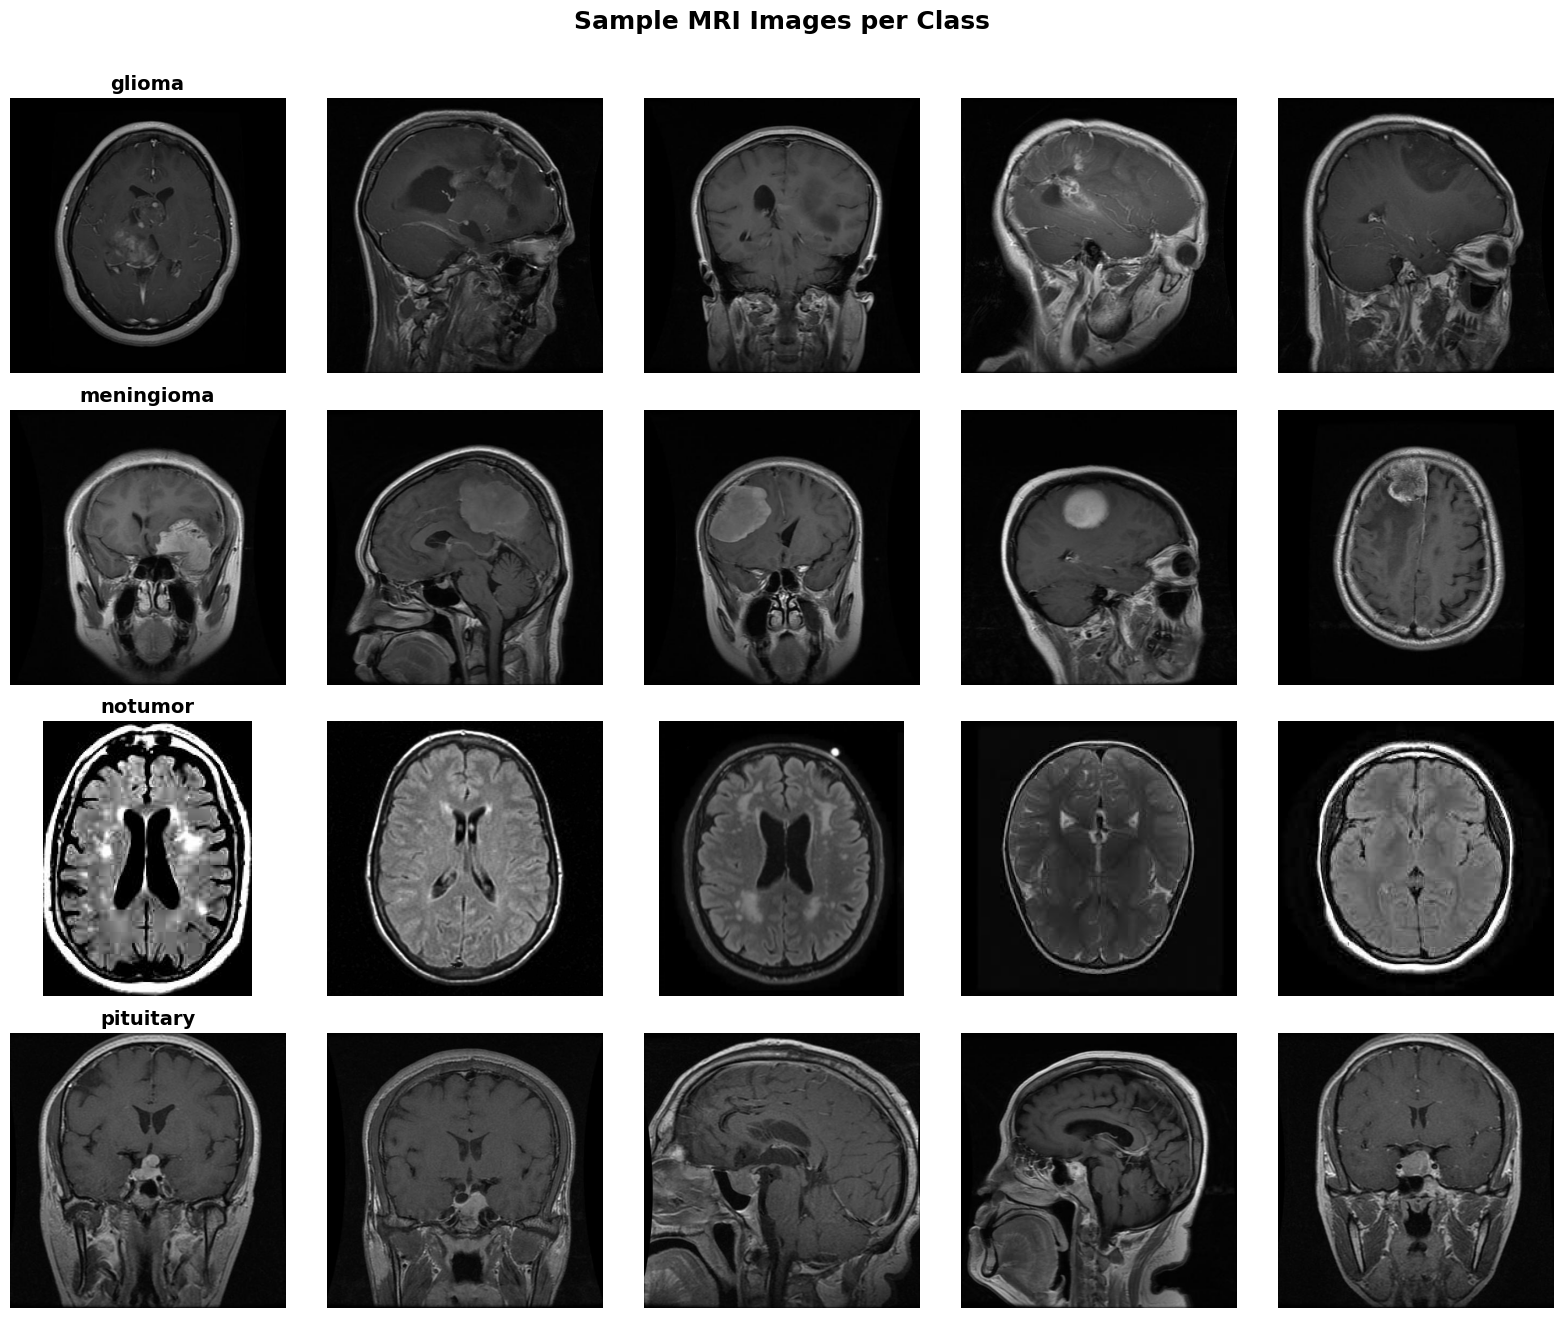

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Sample MRI Images per Class', fontsize=18, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    class_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(class_path)
    sample_images = random.sample(images, 5)

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(cls, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Class Distribution Bar Chart

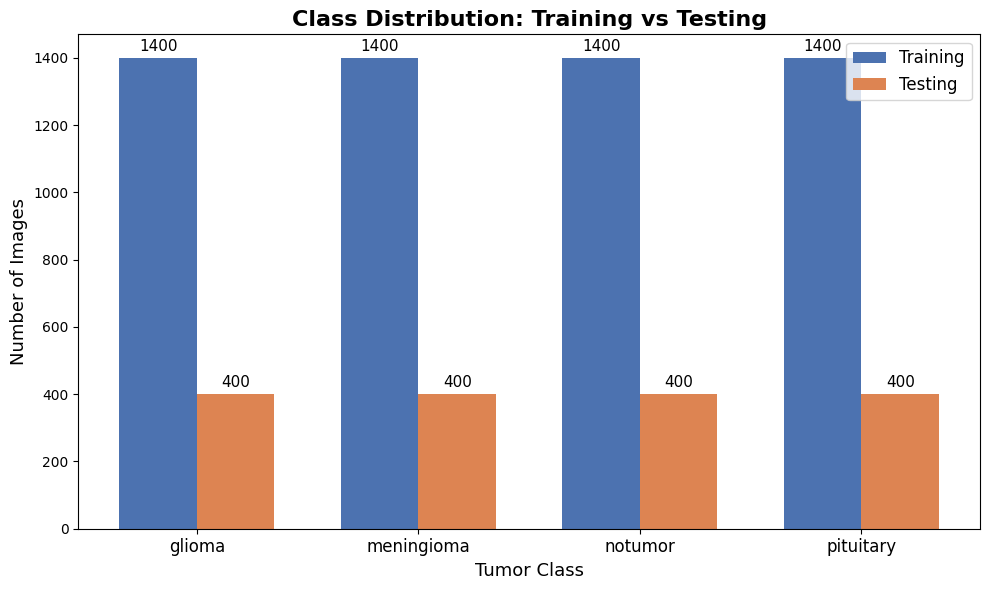

✅ Dataset is perfectly balanced — 1400 train / 400 test per class


In [ ]:
train_counts = []
test_counts = []

for cls in CLASS_NAMES:
    train_counts.append(len(os.listdir(os.path.join(TRAIN_DIR, cls))))
    test_counts.append(len(os.listdir(os.path.join(TEST_DIR, cls))))

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_counts, width, label='Training', color='#4C72B0')
bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', color='#DD8452')

ax.set_xlabel('Tumor Class', fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('Class Distribution: Training vs Testing', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.legend(fontsize=12)

# Add count labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{int(bar.get_height())}', ha='center', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{int(bar.get_height())}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Dataset is perfectly balanced — 1400 train / 400 test per class")


### Image Size Distribution

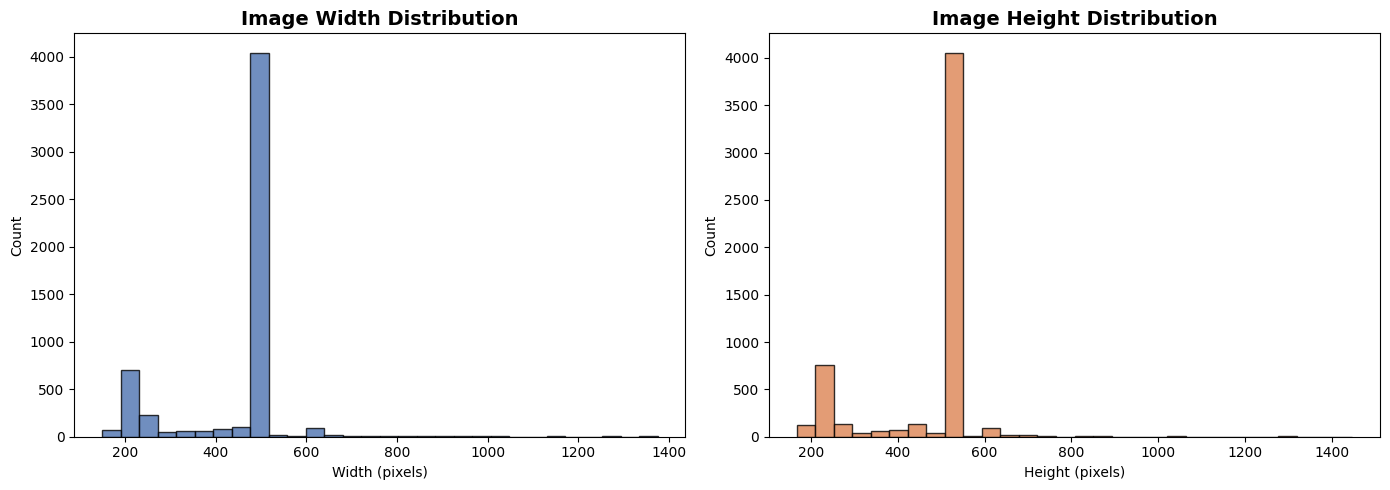


📐 Width  — Min: 150, Max: 1375, Mean: 459
📐 Height — Min: 168, Max: 1446, Mean: 462

➡️ Images have variable sizes — we will resize all to 224×224 in preprocessing


In [ ]:
widths = []
heights = []

# Sample from each class to check size distribution
for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].set_title('Image Width Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=30, color='#DD8452', edgecolor='black', alpha=0.8)
axes[1].set_title('Image Height Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\n📐 Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"📐 Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")
print(f"\n➡️ Images have variable sizes — we will resize all to 224×224 in preprocessing")


## Section 3 & 4: Preprocessing & Data Augmentation

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Training generator — WITH augmentation + validation split
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ResNet50-specific normalization
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.15
)

# Test generator — NO augmentation, only ResNet50 preprocessing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [ ]:
# Training set (75% of Training folder)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Validation set (15% of Training folder)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Test set (separate Testing folder — no augmentation)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Training samples:   {train_generator.samples}")
print(f"✅ Validation samples: {val_generator.samples}")
print(f"✅ Testing samples:    {test_generator.samples}")
print(f"\n📋 Class mapping: {train_generator.class_indices}")


Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

✅ Training samples:   4760
✅ Validation samples: 840
✅ Testing samples:    1600

📋 Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


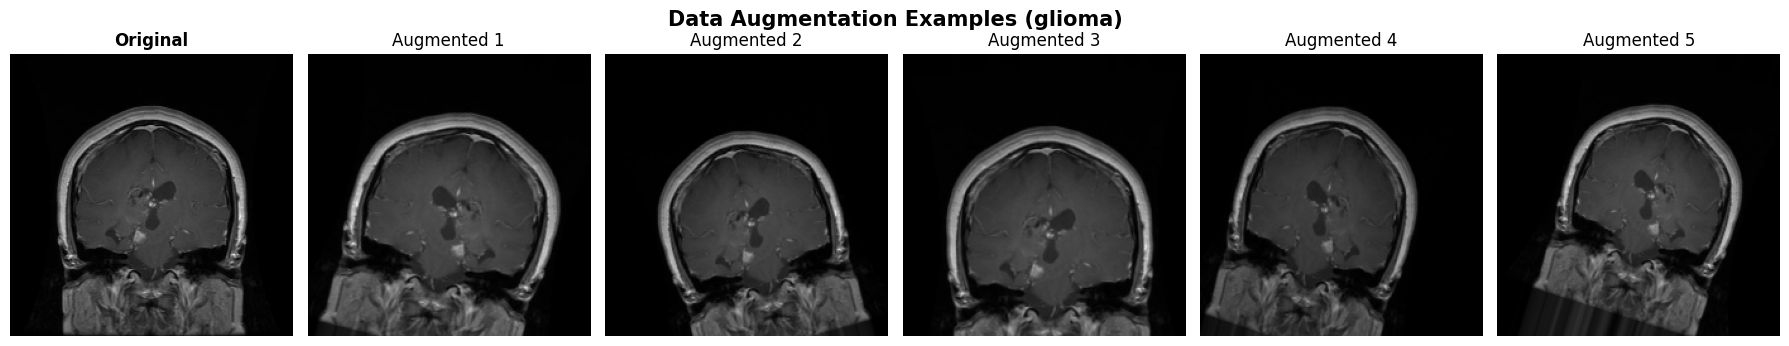

In [ ]:
# Show original vs augmented versions of one image
sample_class = 'glioma'
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_img_name = os.listdir(sample_path)[0]
sample_img = cv2.imread(os.path.join(sample_path, sample_img_name))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))

# Generate augmented versions
aug_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

img_array = sample_img.reshape((1,) + sample_img.shape)

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
axes[0].imshow(sample_img)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = next(aug_datagen.flow(img_array, batch_size=1))[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}', fontsize=12)
    axes[i].axis('off')

fig.suptitle(f'Data Augmentation Examples ({sample_class})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# Section 5 — ResNet50 Model Architecture.

### Build The Model

In [ ]:
# Load pre-trained ResNet50 (without top classification layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all base layers initially
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,668 (92.11 MB)

 Trainable params: 557,956 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Check Layer Counts

In [ ]:
print(f"Total layers:     {len(model.layers)}")
print(f"Trainable:        {len([l for l in model.layers if l.trainable])}")
print(f"Non-trainable:    {len([l for l in model.layers if not l.trainable])}")
print(f"\nTotal params:     {model.count_params():,}")


Total layers:     181
Trainable:        6
Non-trainable:    175

Total params:     24,145,668


# Section 6: Training (Two Stages)

 Define Callbacks

In [ ]:
# Create folder to save model in Drive
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'resnet50_stage1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks ready. Model will be saved to:", MODEL_DIR)


✅ Callbacks ready. Model will be saved to: /content/drive/MyDrive/DLP_Project/models


Stage 1: Train with Frozen Base

In [ ]:
print("=" * 60)
print("STAGE 1: Feature Extraction (Frozen Base)")
print("=" * 60)

EPOCHS_STAGE1 = 15

history_stage1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=val_generator,
    callbacks=callbacks
)

print("\n✅ Stage 1 complete!")
print(f"Best val accuracy: {max(history_stage1.history['val_accuracy']):.4f}")


STAGE 1: Feature Extraction (Frozen Base)
Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.5861 - loss: 1.0787
Epoch 1: val_accuracy improved from None to 0.83929, saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_stage1_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 144s 864ms/step - accuracy: 0.6958 - loss: 0.7758 - val_accuracy: 0.8393 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.8109 - loss: 0.4953
Epoch 2: val_accuracy improved from 0.83929 to 0.86548, saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_stage1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_stage1_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 109s 729ms/step - accuracy: 0.8170 - loss: 0.4815 - val_accuracy: 0.8655 - val_loss: 0.3680 - learning_rate: 0.0010
Epoch

Stage 2: Fine-Tune Top Layers

In [ ]:
print("=" * 60)
print("STAGE 2: Fine-Tuning (Unfreezing top layers)")
print("=" * 60)

# Unfreeze the last 30 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = len([l for l in model.layers if l.trainable])
print(f"Trainable layers now: {trainable_count}")

# Recompile with a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Update checkpoint path for stage 2
callbacks_stage2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'resnet50_final_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS_STAGE2 = 15

history_stage2 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=val_generator,
    callbacks=callbacks_stage2
)

print("\n✅ Stage 2 complete!")
print(f"Best val accuracy: {max(history_stage2.history['val_accuracy']):.4f}")


STAGE 2: Fine-Tuning (Unfreezing top layers)
Trainable layers now: 36
Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.8574 - loss: 0.4337
Epoch 1: val_accuracy improved from None to 0.91905, saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_final_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_final_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 145s 833ms/step - accuracy: 0.8849 - loss: 0.3414 - val_accuracy: 0.9190 - val_loss: 0.2375 - learning_rate: 1.0000e-05
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9128 - loss: 0.2278
Epoch 2: val_accuracy improved from 0.91905 to 0.93333, saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_final_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DLP_Project/models/resnet50_final_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 109s 728ms/step - accuracy: 0.9218 - loss: 0.2150 - val_accuracy: 0.9333 - val_loss: 0.1813 -

Plot Training Curves (Both Stages Combined)

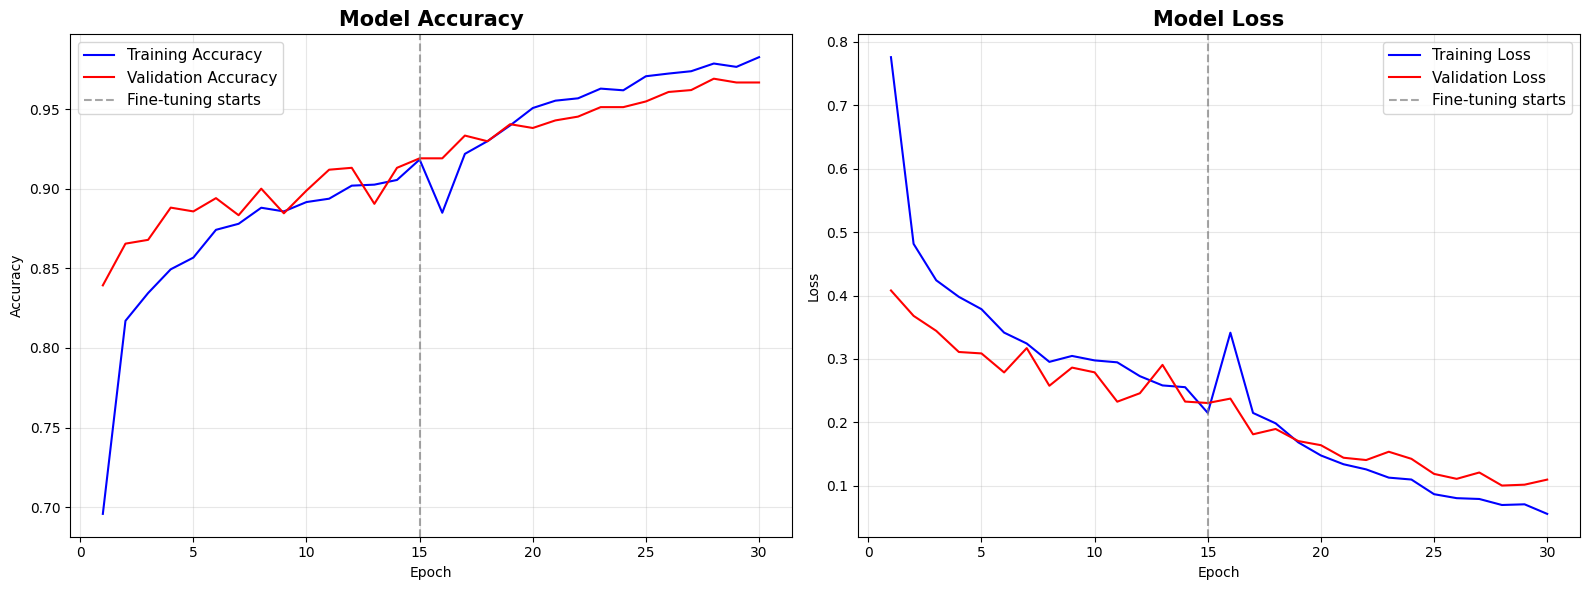

In [ ]:
# Combine histories
acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']
epochs_range = range(1, len(acc) + 1)
stage1_end = len(history_stage1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
axes[0].plot(epochs_range, acc, 'b-', label='Training Accuracy')
axes[0].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[0].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[0].set_title('Model Accuracy', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, loss, 'b-', label='Training Loss')
axes[1].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[1].axvline(x=stage1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning starts')
axes[1].set_title('Model Loss', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Section 7: Classification Evaluation

### Test Set Predictions

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predictions on test set
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Class names from generator
class_labels = list(test_generator.class_indices.keys())

test_accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


50/50 ━━━━━━━━━━━━━━━━━━━━ 487s 10s/step

🎯 Test Accuracy: 0.9313 (93.12%)


Classification Report

In [ ]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.96      0.81      0.88       400
  meningioma       0.88      0.93      0.90       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



Confusion Matrix

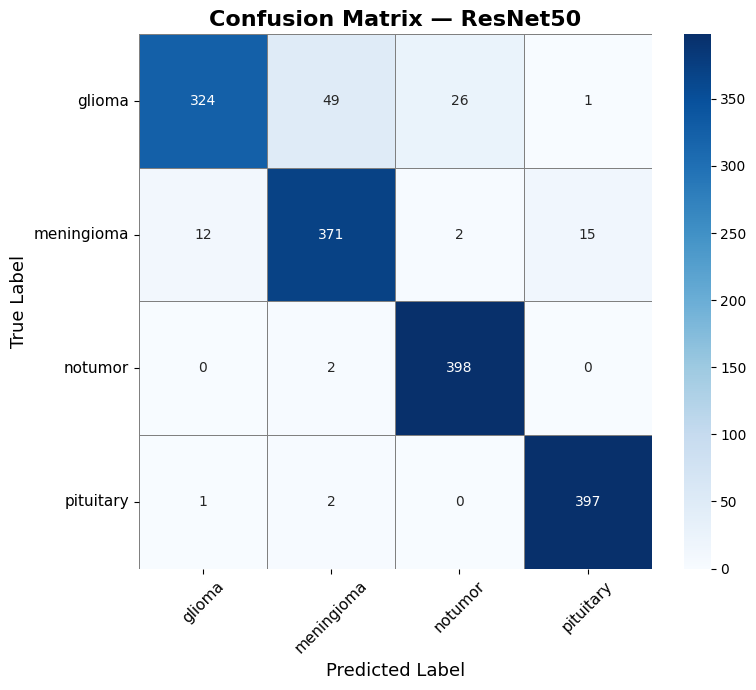

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — ResNet50', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(fontsize=11, rotation=45)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()


ROC-AUC Curves

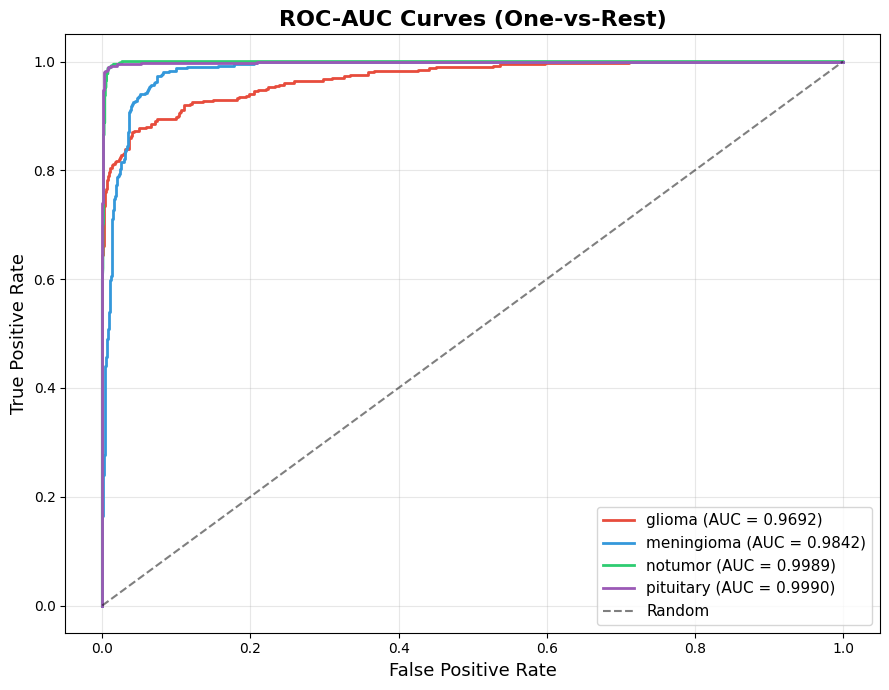


📊 Overall ROC-AUC (macro): 0.9878


In [ ]:
  # Binarize true labels for ROC computation
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{class_labels[i]} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC-AUC Curves (One-vs-Rest)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Overall AUC
overall_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')
print(f"\n📊 Overall ROC-AUC (macro): {overall_auc:.4f}")


# Section 8: Grad-CAM Localization

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


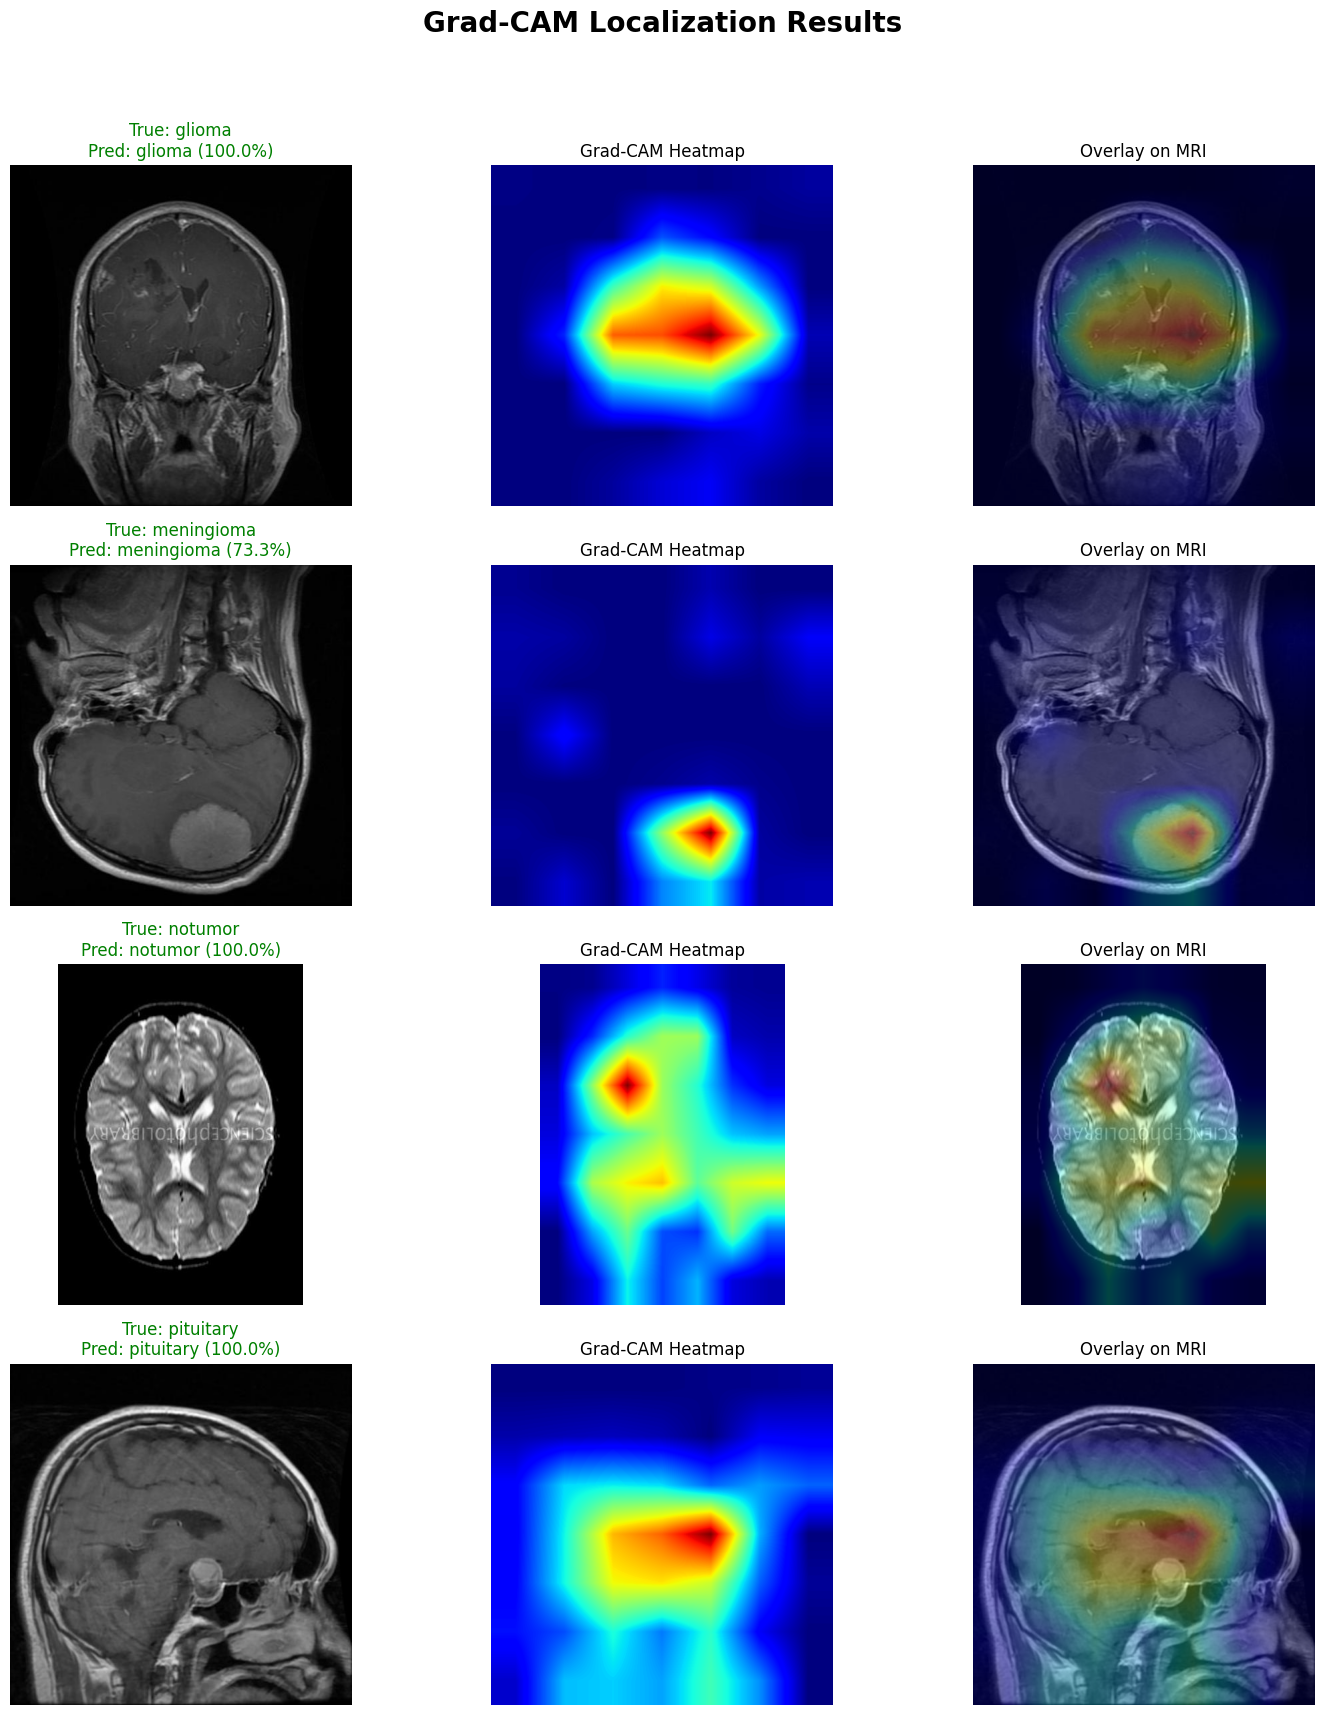

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 3. This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4. We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. For visualization purpose, we will also normalize the heatmap between 0 & 1
    # applying ReLU to only keep positive influence
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the heatmap to have the same size as the original image
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert the heatmap to RGB
    heatmap_rgb = np.uint8(255 * heatmap)

    # We use jet colormap to colorize heatmap
    jet = plt.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_rgb]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    return img, heatmap_rgb, superimposed_img

# The last convolutional layer in ResNet50
last_conv_layer_name = "conv5_block3_out"

# Pick one sample from each class in the test set
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(15, 18))
fig.suptitle('Grad-CAM Localization Results', fontsize=20, fontweight='bold', y=0.98)

from tensorflow.keras.applications.resnet50 import preprocess_input

for i, cls in enumerate(CLASS_NAMES):
    # Get a random image from this class in the test set
    class_dir = os.path.join(TEST_DIR, cls)
    img_name = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, img_name)

    # Load and preprocess image for the model
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = preprocess_input(np.expand_dims(img_resized, axis=0))

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_class = CLASS_NAMES[pred_idx]
    confidence = preds[0][pred_idx] * 100

    # Generate Heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Get visuals
    orig, heat_only, superimposed = display_gradcam(img_path, heatmap)

    # Plot Original
    axes[i, 0].imshow(orig)
    title_color = 'green' if pred_class == cls else 'red'
    axes[i, 0].set_title(f"True: {cls}\nPred: {pred_class} ({confidence:.1f}%)", color=title_color, fontsize=12)
    axes[i, 0].axis('off')

    # Plot Heatmap
    axes[i, 1].imshow(heat_only, cmap='jet')
    axes[i, 1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[i, 1].axis('off')

    # Plot Overlay
    axes[i, 2].imshow(superimposed)
    axes[i, 2].set_title("Overlay on MRI", fontsize=12)
    axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Section 9: Localization IoU Evaluation

In [ ]:
def calculate_iou(cam_heatmap, original_img, threshold=0.5):
    """
    Calculates an approximate IoU by thresholding the Grad-CAM heatmap
    and comparing it against an intensity-based mask of the original image.
    """
    # 1. Create binary mask from Grad-CAM (threshold at 50% of max intensity)
    cam_mask = (cam_heatmap > threshold).astype(np.uint8)

    # 2. Create approximate "ground truth" mask using Otsu's thresholding
    # Convert original to grayscale
    gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Otsu's thresholding to find the brightest regions (often tumors in MRI)
    _, gt_mask = cv2.threshold(blurred, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Resize gt_mask to match cam_mask dimensions
    gt_mask = cv2.resize(gt_mask, (cam_mask.shape[1], cam_mask.shape[0]))

    # 3. Calculate Intersection and Union
    intersection = np.logical_and(cam_mask, gt_mask).sum()
    union = np.logical_or(cam_mask, gt_mask).sum()

    # Avoid division by zero
    if union == 0:
        return 0.0

    iou = intersection / union
    return iou


In [ ]:
# Evaluate IoU on 50 random test images (excluding 'notumor' class)
tumor_classes = [cls for cls in CLASS_NAMES if cls != 'notumor']
sample_size = 50
ious = {cls: [] for cls in tumor_classes}

print(f"Calculating approximate IoU over {sample_size} sample images per tumor class...")

for cls in tumor_classes:
    class_dir = os.path.join(TEST_DIR, cls)
    # Select random sample of images
    sample_images = random.sample(os.listdir(class_dir), min(sample_size, len(os.listdir(class_dir))))

    for img_name in sample_images:
        img_path = os.path.join(class_dir, img_name)

        # Load and preprocess
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_array = preprocess_input(np.expand_dims(img_resized, axis=0))

        # Generate Heatmap
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        # Calculate IoU
        iou = calculate_iou(heatmap, img_resized, threshold=0.5)
        ious[cls].append(iou)

print("\n--- Approximate Localization IoU Results ---")
overall_ious = []
for cls in tumor_classes:
    avg_iou = np.mean(ious[cls])
    overall_ious.extend(ious[cls])
    print(f"{cls.capitalize():>12}: {avg_iou:.4f}")

print("-" * 42)
print(f"{'Overall Avg':>12}: {np.mean(overall_ious):.4f}")
print("\nNote: Grad-CAM is weakly supervised. Scores ~0.3-0.5 indicate reasonable localization without explicit bounding box training data.")


Calculating approximate IoU over 50 sample images per tumor class...

--- Approximate Localization IoU Results ---
      Glioma: 0.3052
  Meningioma: 0.2488
   Pituitary: 0.2869
------------------------------------------
 Overall Avg: 0.2803

Note: Grad-CAM is weakly supervised. Scores ~0.3-0.5 indicate reasonable localization without explicit bounding box training data.


## Section 10: Comparison with Existing Methods

Plot Comparison Table

COMPARISON WITH EXISTING METHODS
                      Method          Architecture  Accuracy (%)  Localization?
           Nickparvar (2021)            Custom CNN          92.0             No
       Deepak & Ameer (2019)  GoogleNet (Transfer)          98.0             No
         Swati et al. (2019) VGG19 (Block-wise FT)          94.8             No
Badza & Barjaktarovic (2020)            Custom CNN          96.6             No
    Abiwinanda et al. (2019)            Simple CNN          84.2             No
         Our Proposed System ResNet50 (Fine-Tuned)          93.1 Yes (Grad-CAM)


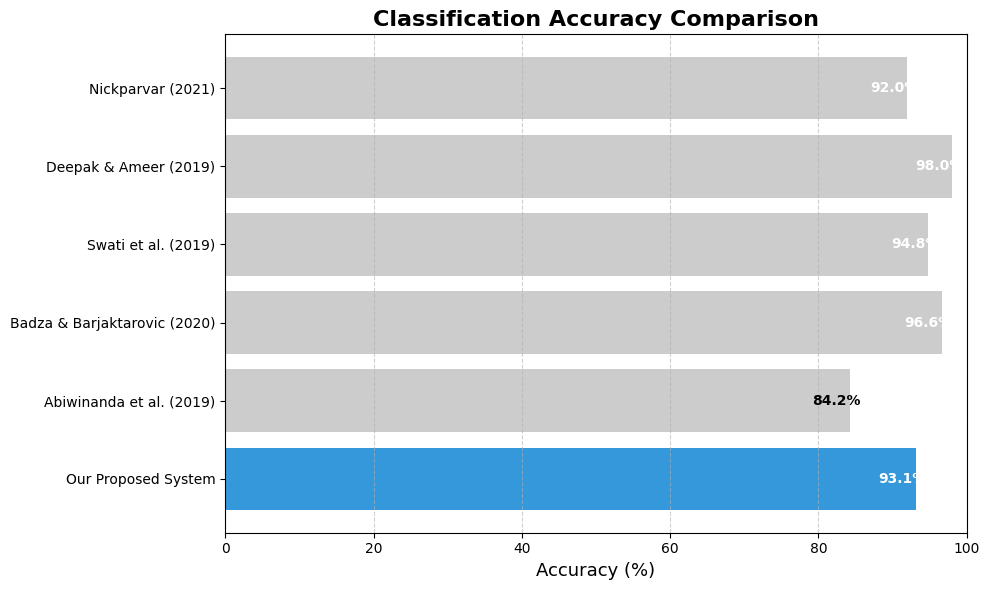


Conclusion: Our model achieves competitive accuracy while adding crucial clinical interpretability via Grad-CAM.


In [ ]:
# Data based on literature review of brain tumor classification models

comparison_data = {
    'Method': [
        'Nickparvar (2021)',
        'Deepak & Ameer (2019)',
        'Swati et al. (2019)',
        'Badza & Barjaktarovic (2020)',
        'Abiwinanda et al. (2019)',
        'Our Proposed System'
    ],
    'Architecture': [
        'Custom CNN',
        'GoogleNet (Transfer)',
        'VGG19 (Block-wise FT)',
        'Custom CNN',
        'Simple CNN',
        'ResNet50 (Fine-Tuned)'
    ],
    'Accuracy (%)': [
        92.0,
        98.0,
        94.8,
        96.6,
        84.2,
        round(test_accuracy * 100, 1)  # Using your actual test accuracy
    ],
    'Localization?': [
        'No',
        'No',
        'No',
        'No',
        'No',
        'Yes (Grad-CAM)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Print the table nicely
print("=" * 80)
print("COMPARISON WITH EXISTING METHODS")
print("=" * 80)
print(df_comparison.to_string(index=False))
print("=" * 80)

# Optional: Plot a bar chart comparing accuracies
plt.figure(figsize=(10, 6))
colors = ['#cccccc' if m != 'Our Proposed System' else '#3498db' for m in df_comparison['Method']]
bars = plt.barh(df_comparison['Method'], df_comparison['Accuracy (%)'], color=colors)

# Add text labels on bars
for bar in bars:
    plt.text(bar.get_width() - 5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width()}%",
             va='center', color='black' if bar.get_width() < 90 else 'white', fontweight='bold')

plt.title('Classification Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy (%)', fontsize=13)
plt.xlim(0, 100)
plt.gca().invert_yaxis()  # Highest accuracy at top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nConclusion: Our model achieves competitive accuracy while adding crucial clinical interpretability via Grad-CAM.")
